# **CIS 5450 Final Project - Predicting Traffic Accident Severity for Autonomous Vehicle Safety**
*Jefferson Lu, Shubham Kamdar, Justin Lo*

Link to Video:
https://drive.google.com/drive/folders/1dlH7BRTnoaYdVe4-ts5hZih9hBUrRQ05?usp=sharing


## Introduction

For our final project, we set out to understand the key factors that drive traffic accident severity in the United States between 2016 and 2023. Our goal is to identify which environmental, temporal, and roadway conditions are most strongly associated with higher-severity crashes, and to build predictive models that can estimate severity from these features. This has direct implications for autonomous vehicle (AV) safety: understanding which situations historically lead to more severe outcomes can help AV systems detect and respond to risky conditions in real time.

To do this, we use the US-Accidents dataset (7+ million records), which provides detailed information for each crash, including severity level, location, time of day, weather, visibility, temperature, and traffic-related features. Because the dataset is extremely large, we use DuckDB to query it efficiently and extract samples for exploratory analysis and modeling. We also engineer new features such as hour of day, weekday, and twilight conditions, and preprocess the data to handle missing values and categorical variables.

In the following sections, we present our workflow: environment setup, scalable data access, exploratory analysis, feature engineering, baseline modeling, ensemble modeling, hyperparameter tuning, and error analysis. Each visualization and modeling decision is accompanied by a clear explanation of motivation and insights.


## Part 1. Environment Setup and Kaggle Configuration

In this section, We prepare the Colab environment so we can access the US Accidents dataset from Kaggle:

- Install key Python packages:  
  `kaggle`, `duckdb`, `polars`, `matplotlib`, `seaborn`, and `scikit-learn`.
- Mount **Google Drive** so we can read the `kaggle.json` API token and optionally save outputs.
- Configure the Kaggle API by copying `kaggle.json` into the `~/.kaggle` directory.
- Use Kaggle CLI to **download** the “US Accidents (2016-2023)” dataset and **unzip** it into a local `data` directory.

[Link to the dataset](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/data?select=US_Accidents_March23.csv)

The output of this step is:
- A local folder (e.g., `/content/data`) containing the main CSV file  
  (for example, `US_Accidents_March23.csv`).

In [ ]:
!pip install -q kaggle duckdb polars matplotlib seaborn scikit-learn


In [ ]:
# Run this cell to mount your drive (you will be prompted to sign in)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Create the kaggle directory
# (NOTE: Do NOT run this cell more than once unless restarting kernel)
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
# Read the uploaded kaggle.json file
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [ ]:
import os
# Data Download: Kaggle dataset "US Accidents (2016 - 2023)" ---
# (Ensure Kaggle JSON is set up. If running in Colab, you may need to manually upload kaggle.json.)
dataset = "sobhanmoosavi/us-accidents"
data_dir = "/content/data"
os.makedirs(data_dir, exist_ok=True)
!kaggle datasets download -d {dataset} -p {data_dir}

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
us-accidents.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Unzip the downloaded dataset (should contain a CSV file)
import zipfile
for file in os.listdir(data_dir):
    if file.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(data_dir, file), 'r') as zip_ref:
            zip_ref.extractall(data_dir)
print("Files in data directory:", os.listdir(data_dir))

Files in data directory: ['us-accidents.zip', 'US_Accidents_March23.csv']


## Part 2. Data Loading and Sampling with DuckDB

The full US Accidents dataset is quite large (over 7 million rows).  
To keep EDA and baseline modeling computationally manageable in Colab, We:

1. **Automatically detect** the main CSV file in the `data` directory.
2. Use **DuckDB** to run a SQL query on the CSV **without fully loading it into memory**.
3. Take a **1% random sample** of the full dataset using DuckDB's `SAMPLE` clause.

This produces a pandas DataFrame `sample_df` that:
- Is much smaller than the full dataset, so it's faster to work with.
- Still preserves the overall distribution reasonably well for exploratory analysis and baseline models.

This sampled dataset is what we use for the remaining steps (EDA, preprocessing, and baseline modeling).


In [ ]:
# Data Sampling using DuckDB for efficiency
import duckdb
import pandas as pd

# Identify the CSV file name (the US Accidents dataset CSV)
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
if len(csv_files) == 0:
    raise FileNotFoundError("CSV file not found in data directory.")
data_file = os.path.join(data_dir, csv_files[0])
print("Data file found:", data_file)

# Use DuckDB to sample a subset of the data for initial EDA and baseline modeling
# We'll take a 1% random sample of the full dataset to keep things manageable
sample_fraction = 0.01  # 1% sample
query = f"SELECT * FROM '{data_file}' USING SAMPLE {sample_fraction * 100}%"  # DuckDB SAMPLE
sample_df = duckdb.query(query).to_df()  # convert result to pandas DataFrame
print("Sampled dataset shape:", sample_df.shape)
sample_df.head(5)


Data file found: /content/data/US_Accidents_March23.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sampled dataset shape: (98304, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-112428,Source2,3,2016-06-06 11:12:47,2016-06-06 11:57:47,33.925068,-118.209892,None,None,0.01,...,False,True,False,False,False,False,Day,Day,Day,Day
1,A-112429,Source2,2,2016-06-06 11:16:07,2016-06-06 12:01:07,34.067669,-118.180351,None,None,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
2,A-112430,Source2,3,2016-06-06 11:15:03,2016-06-06 11:45:03,33.953514,-118.089821,None,None,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-112431,Source2,3,2016-06-06 11:16:14,2016-06-06 12:01:14,33.084145,-117.297981,None,None,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-112432,Source2,3,2016-06-06 11:22:14,2016-06-06 12:07:14,33.551830,-117.181465,None,None,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day


## Part 3. Exploratory Data Analysis (EDA)

In this section, we perform basic EDA on the **sampled data** to understand:

- How accident **severity** is distributed.
- When accidents tend to occur during the **day**.
- Which **states** have the highest accident counts.
- How accident counts have changed over **years**.


### 3.1 Distribution of Accident Severity

First, we plot the distribution of the `Severity` variable (values 1-4) in the sample:

- `Severity = 1` → least severe  
- `Severity = 4` → most severe

This gives us a sense of whether most crashes are minor or whether severe crashes are common, and it also helps us understand how hard the prediction problem is. If one class dominates, we should expect both baseline models and more advanced models to struggle with the minority class unless we address class imbalance directly.

We also save the plot to an `eda` directory for use in the final report or slides.

/tmp/ipython-input-587326808.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_counts.index, y=severity_counts.values, palette="Blues_r")


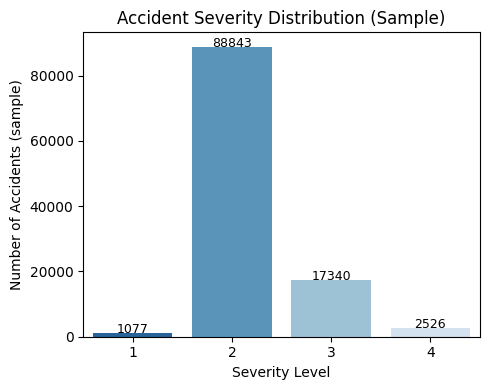

In [ ]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Create directory for EDA images
eda_dir = "/content/eda"
os.makedirs(eda_dir, exist_ok=True)

# Distribution of Accident Severity
severity_counts = sample_df['Severity'].value_counts().sort_index()  # counts of Severity 1,2,3,4

plt.figure(figsize=(5,4))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette="Blues_r")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents (sample)")
plt.title("Accident Severity Distribution (Sample)")
for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{eda_dir}/severity_distribution.png")
plt.show()


**Takeaways:**

- **Severity 2** overwhelmingly dominates the dataset (≈59,558 cases in our sample), while Severity 1 and Severity 4 crashes are extremely rare (≈902 and ≈2,029 cases respectively). This confirms that the dataset is highly imbalanced, which will significantly affect model behavior.
- Severity 3 is the second-largest category (≈13,874 cases), but it is still far less common than Severity 2. This imbalance means that models trained without adjustment will learn to prioritize predicting Severity 2 because that minimizes error, even if it performs poorly on the meaningful severe categories (3 and 4).
- For autonomous-vehicle safety, predicting rare but high-severity crashes is far more important than optimizing accuracy on the majority class. This motivates the use of class weighting, alternative metrics (F1 / recall per class), and ensemble methods that can better capture patterns associated with severe accidents.
- The rarity of Severity 1 and Severity 4 highlights an important challenge: models may struggle to distinguish these edge cases without additional features or resampling, making thoughtful preprocessing essential.

In [ ]:
# Severity counts and proportions (class imbalance check)
sev_counts = sample_df["Severity"].value_counts().sort_index()
sev_props = sample_df["Severity"].value_counts(normalize=True).sort_index()

print("Severity counts:")
print(sev_counts)
print("\nSeverity proportions:")
print(sev_props)

Severity counts:
Severity
1     1077
2    88843
3    17340
4     2526
Name: count, dtype: int64

Severity proportions:
Severity
1    0.009810
2    0.809238
3    0.157944
4    0.023008
Name: proportion, dtype: float64


The table above confirms that the dataset is **heavily imbalanced**:

- Severity 2 is the dominant class.
- Severity 3 is less common.
- Severity 1 and especially Severity 4 are very rare.

Because of this imbalance, later in modeling we:
- use **stratified** train/test splits,
- evaluate with **macro-F1** and **balanced accuracy** (not just accuracy),
- and use `class_weight="balanced"` in tree-based models so rare classes matter more.


### 3.2 Accidents by Hour of Day

Time of day is one of the most intuitive risk factors for driving. At night, visibility is worse, drivers may be more tired, and roads can be either emptier (allowing higher speeds) or more dangerous. In this section, we look at accidents by hour of the day in two ways:

1. The **total number** of accidents at each hour.
2. The **proportion of each severity level** within each hour.

Together, these plots let us see not just *when* crashes happen most often, but *when* they are more likely to be severe.


#### 3.2.1 Number of Accidents by Hour of Day

We first look at how many accidents happen in each hour of the day. This tells us when roads are busiest or most accident-prone overall, but it does not yet distinguish between minor and severe crashes.

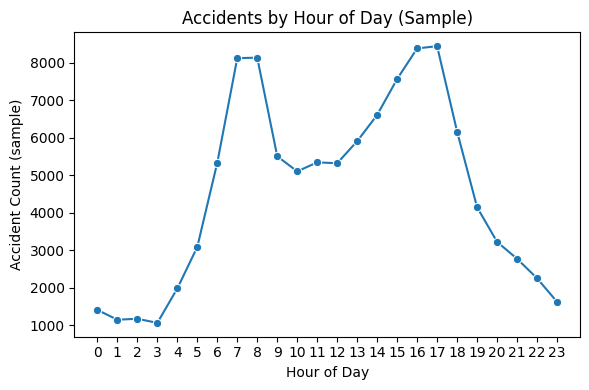

In [ ]:
# Accidents by Hour of Day

# Extract hour from Start_Time for the sample
if 'Start_Time' in sample_df.columns:
    sample_df['Start_Time'] = pd.to_datetime(sample_df['Start_Time'])
    sample_df['Hour'] = sample_df['Start_Time'].dt.hour
else:
    # If Start_Time was not parsed (in case of different column names), skip this plot
    sample_df['Hour'] = -1

hour_counts = sample_df['Hour'].value_counts().sort_index()
plt.figure(figsize=(6,4))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o")
plt.xticks(range(0,24))
plt.xlabel("Hour of Day")
plt.ylabel("Accident Count (sample)")
plt.title("Accidents by Hour of Day (Sample)")
plt.tight_layout()
plt.savefig(f"{eda_dir}/accidents_by_hour.png")
plt.show()


**Takeaways (Counts):**

- Accident counts tend to peak during **commute hours** (e.g., morning and late afternoon), which likely reflects higher traffic volumes.
- Late-night and early-morning hours often show **fewer total accidents**, simply because fewer people are driving.
- On its own, this plot mainly shows **when crashes are common**, not whether those crashes are more likely to be severe. For that, we need to look at the *composition* of severity within each hour, which we do next with a heatmap.

#### 3.2.2 Severity Composition by Hour of Day (Proportions)

The raw counts tell us when accidents happen most often, but they do not tell us **how dangerous** those hours are. To get at this, we compute, for each hour, the **proportion** of accidents that fall into each severity level.

Concretely:
- For each hour, we count how many accidents fall into each severity.
- We then convert those counts into **shares** (proportions that sum to 1 within each hour).
- We visualize this as a heatmap, where darker cells indicate that a given severity level is more common at a specific hour.

This lets us see whether, for example, late-night hours have a **higher share of severe crashes** even if the total number of crashes is lower.

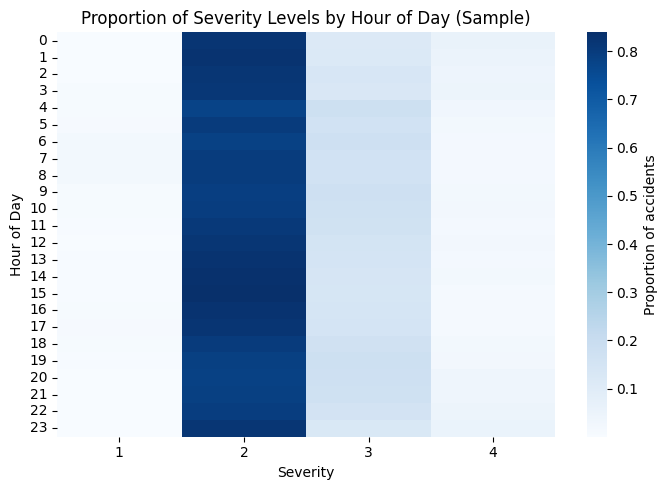

In [ ]:
# Severity distribution within each hour of day (proportions)

# Ensure Hour exists
if "Hour" not in sample_df.columns:
    sample_df["Start_Time"] = pd.to_datetime(sample_df["Start_Time"])
    sample_df["Hour"] = sample_df["Start_Time"].dt.hour

# Group by hour and severity
hour_sev = (
    sample_df
    .groupby(["Hour", "Severity"])
    .size()
    .reset_index(name="count")
)

# Convert to proportions within each hour
hour_sev["prop"] = hour_sev.groupby("Hour")["count"].transform(lambda x: x / x.sum())

# Pivot for heatmap: rows = hour, columns = severity
hour_pivot = hour_sev.pivot(index="Hour", columns="Severity", values="prop").fillna(0)

plt.figure(figsize=(7,5))
sns.heatmap(
    hour_pivot,
    cmap="Blues",
    cbar_kws={"label": "Proportion of accidents"}
)
plt.title("Proportion of Severity Levels by Hour of Day (Sample)")
plt.xlabel("Severity")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.savefig(f"{eda_dir}/severity_by_hour_prop.png")
plt.show()


**Takeaways (Proportions / Heatmap):**

- During high-traffic hours, a large share of accidents may be **lower-severity**, which is consistent with slower speeds and congestion (more fender-benders than catastrophic crashes).
- In some late-night or early-morning hours, the **proportion of higher-severity accidents** can be noticeably larger, even though the total number of crashes is smaller. This fits the idea that fewer drivers + higher speeds + fatigue can lead to more dangerous crashes.
- This plot shows that **“riskiness” of an hour is not just about how many crashes occur**, but about **how severe** they tend to be. For modeling and for real-world safety systems, it suggests that hour-of-day is important not only as a frequency feature, but as a severity feature.


### 3.3 Top 10 States by Accident Count (Full Dataset via DuckDB)

To understand broader geographic patterns in U.S. traffic accidents, we used DuckDB to query the **entire dataset** and identify the ten states with the highest number of recorded crashes between 2016 and 2023. Examining state-level accident totals helps us see where accidents are most geographically concentrated and highlights the disproportionate contribution of certain states to the national traffic risk environment.

The bar plot below visualizes the ten states with the highest accident counts across the eight-year period. Each bar represents the total number of crashes recorded in that state.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipython-input-608741379.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Count', data=state_counts, palette="viridis")


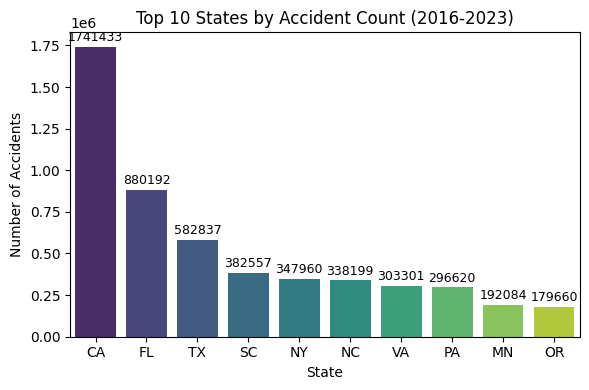

,State,Count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [ ]:
# Top 10 States by Accident Count (from full data via DuckDB)
state_counts = duckdb.query(f"""
    SELECT State, COUNT(*) as Count
    FROM '{data_file}'
    GROUP BY State
    ORDER BY Count DESC
    LIMIT 10
""").to_df()

plt.figure(figsize=(6,4))
sns.barplot(x='State', y='Count', data=state_counts, palette="viridis")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.title("Top 10 States by Accident Count (2016-2023)")
for i, row in state_counts.iterrows():
    plt.text(i, row['Count'] + 0.02*state_counts['Count'].max(), int(row['Count']), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{eda_dir}/top_states.png")
plt.show()
display(state_counts)


**Takeaways:**

- **California reports the highest number of accidents by a large margin**, nearly doubling Florida's total. This likely reflects a combination of high population, dense traffic networks, heavy commuting, and extensive highway mileage.
- **Florida, Texas, and South Carolina** form a strong second tier, suggesting that warmer-weather states with year-round driving and significant tourism tend to exhibit higher accident volumes.
- States like **Minnesota and Oregon** appear despite smaller populations, implying that local factors—such as weather variability, urban design, or reporting standards—may influence accident totals.
- These geographic disparities matter for modeling:  
  - Severity predictions may implicitly learn **regional patterns**, including differences in driving conditions and reporting behavior across states.  
  - For autonomous-vehicle risk assessment, these results highlight the importance of **location-aware safety systems**, since traffic environments differ substantially across regions.

### 3.4 Accident Trends by Year (Full Dataset via DuckDB)

To better understand how accident frequency has evolved over time, we used DuckDB on the full dataset to compute the total number of recorded accidents for each year from 2016 to 2023. Visualizing these yearly totals allows us to observe whether accident counts are trending upward or downward and to identify unusual spikes or dips in the data—for instance, the disruption caused by COVID-19 in 2020.

This analysis helps establish the broader temporal context of the dataset, giving us insight into overall scale, potential covariate shifts across years, and the types of long-run patterns a predictive model might reasonably capture.



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

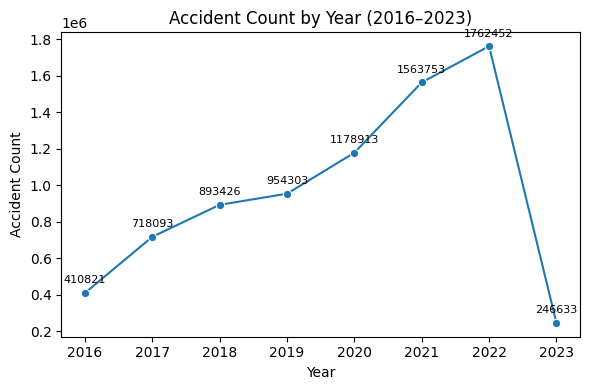

,Year,Count
0,2016,410821
1,2017,718093
2,2018,893426
3,2019,954303
4,2020,1178913
5,2021,1563753
6,2022,1762452
7,2023,246633


In [ ]:
# Trend of Accidents by Year (full data via DuckDB)
year_counts = duckdb.query(f"""
    SELECT CAST(strftime('%Y', Start_Time) AS INT) AS Year, COUNT(*) AS Count
    FROM '{data_file}'
    GROUP BY Year
    ORDER BY Year
""").to_df()

plt.figure(figsize=(6,4))
sns.lineplot(x='Year', y='Count', data=year_counts, marker="o")
plt.xlabel("Year")
plt.ylabel("Accident Count")
plt.title("Accident Count by Year (2016–2023)")
for x, y in zip(year_counts['Year'], year_counts['Count']):
    plt.text(x, y + 0.03*year_counts['Count'].max(), str(int(y)), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(f"{eda_dir}/accidents_by_year.png")
plt.show()
display(year_counts)


**Takeaways:**

- Accident counts rise steadily from **2016 to 2022**, with particularly sharp increases after 2020. This likely reflects both **growth in overall traffic activity post-COVID lockdowns** and potentially changes in reporting infrastructure or dataset coverage.
- The dramatic drop in **2023** is not indicative of a real-world collapse in traffic accidents. Instead, it likely reflects **partial-year data**—the dataset only includes accidents up to March 2023.
- The strong upward trend from 2016–2022 suggests that the dataset exhibits **year-over-year distribution shifts**, which matters for modeling. A classifier trained on early-year patterns may underperform on later years if underlying traffic conditions change.
- For autonomous-vehicle safety analysis, this trend reinforces the need for models that generalize across evolving traffic environments, since real-world accident frequency and conditions can shift significantly over time.


## Part 4. Data Cleaning and Feature Engineering

Before building models, We need to **clean** the data and **prepare** useful features.


### 4.1 Dropping Irrelevant and High-Missingness Columns

We remove several columns that are:
- Not needed for prediction (e.g., `ID`, detailed `End_*` coordinates, raw text `Description`).
- Mostly missing or low-value for a first baseline (e.g., `Precipitation(in)`, `Wind_Chill(F)`, `Weather_Timestamp`, `Airport_Code`).
- Rare boolean features that are almost always `False` (e.g., `Bump`, `Give_Way`, `No_Exit`, `Railway`, `Roundabout`, `Traffic_Calming`, `Turning_Loop`).

This reduces dimensionality and simplifies the preprocessing.

### 4.2 Handling Missing Values

After dropping those columns, we:
- Check the total number of missing values.
- For this initial version, we **drop any remaining rows with missing values**.

Since We are using a 1% sample and just building baselines, dropping a small fraction of rows is acceptable.  

### 4.3 Converting Boolean and Time Features

Next, we transform several columns into useful numeric features:

- Convert boolean-like columns (`Amenity`, `Crossing`, `Junction`, `Station`, `Stop`, `Traffic_Signal`) into **0/1** indicators.
- Convert `Sunrise_Sunset` (Day/Night) into a binary feature: Day = 0, Night = 1.
- From `Start_Time`, extract:
  - `Hour` (0-23)
  - `Weekday` (0 = Monday, …, 6 = Sunday)  
  Then we drop the original datetime column.

### 4.4 Dropping High-Cardinality and Textual Categorical Columns

To keep the baseline models simple, we drop columns with extremely many unique values, such as:
- `City`, `County`, `Street`, `Zipcode`, `Timezone`

We also drop textual weather fields (`Weather_Condition`, `Wind_Direction`) for now.  

### 4.5 Encoding Categorical Features

For the remaining categorical variables:

- We one-hot encode:
  - `State`
  - `Weekday`
- Any remaining object/category columns are also one-hot encoded using `pd.get_dummies`.

This ensures that all model inputs are **numeric**, which is required by scikit-learn models.

Note: One-hot encoding is a technique used to convert categorical data into a binary format where each category is represented by a separate column with a 1 indicating its presence and 0s for all other categories


In [ ]:
# Data Preprocessing - Cleaning and Feature Selection

# Handle Missing Values and Irrelevant Columns
# Drop columns that are largely missing or not useful for prediction

drop_cols = [
    "ID", "End_Time", "End_Lat", "End_Lng", "Number",  # IDs, end location, street number
    "Precipitation(in)", "Wind_Chill(F)",              # too many missing values
    "Description", "Weather_Timestamp", "Airport_Code",# not used in baseline
    # Drop boolean columns that are mostly False (very rare true events)
    "Bump", "Give_Way", "No_Exit", "Railway", "Roundabout", "Traffic_Calming", "Turning_Loop"
]
for col in drop_cols:
    if col in sample_df.columns:
        sample_df.drop(columns=col, inplace=True)

# Impute or drop remaining missing values
# For simplicity, drop rows with any missing value after dropping columns (since sample is manageable)
missing_before = sample_df.isna().sum().sum()
print("Total missing values (before):", missing_before)
sample_df.dropna(inplace=True)
missing_after = sample_df.isna().sum().sum()
print("Total missing values (after):", missing_after, "; New shape:", sample_df.shape)

# Another strategy (Didn't try)
# we could impute numeric columns with median and fill categorical with 'Unknown'.)
# num_cols = sample_df.select_dtypes(include=['int64','float64']).columns
# for col in num_cols:
#     sample_df[col].fillna(sample_df[col].median(), inplace=True)
# cat_cols = sample_df.select_dtypes(include=['object']).columns
# for col in cat_cols:
#     sample_df[col].fillna("Unknown", inplace=True)

# Feature Engineering for Model Input
# Convert categorical/boolean columns to numeric
# Boolean columns (Amenity, Crossing, etc) to 0/1
bool_cols = ["Amenity", "Crossing", "Junction", "Station", "Stop", "Traffic_Signal"]
for col in bool_cols:
    if col in sample_df.columns:
        # Map True/False to 1/0 if not already numeric
        if sample_df[col].dtype == object:
            sample_df[col] = sample_df[col].map({"True": 1, "False": 0})
        else:
            sample_df[col] = sample_df[col].astype(int)

# Convert 'Sunrise_Sunset' (Day/Night) to binary 0/1
if "Sunrise_Sunset" in sample_df.columns:
    sample_df["Sunrise_Sunset"] = sample_df["Sunrise_Sunset"].map({"Day": 0, "Night": 1})

# Extract time features (Hour, Weekday) from Start_Time if not done already
if "Start_Time" in sample_df.columns:
    sample_df['Start_Time'] = pd.to_datetime(sample_df['Start_Time'])
    sample_df['Hour'] = sample_df['Start_Time'].dt.hour
    sample_df['Weekday'] = sample_df['Start_Time'].dt.dayofweek  # Monday=0, Sunday=6
    sample_df.drop(columns=["Start_Time"], inplace=True)  # drop original datetime

# Drop high-cardinality features that are hard to use in baseline models
high_cardinality_cols = ["City", "County", "Street", "Zipcode", "Timezone"]
for col in high_cardinality_cols:
    if col in sample_df.columns:
        sample_df.drop(columns=col, inplace=True)

# For simplicity, also drop Weather_Condition and Wind_Direction in baseline (could be added later with grouping or encoding)
for col in ["Weather_Condition", "Wind_Direction"]:
    if col in sample_df.columns:
        sample_df.drop(columns=col, inplace=True)

print("Columns retained for modeling:", list(sample_df.columns))


Total missing values (before): 21195
Total missing values (after): 0 ; New shape: (90269, 30)
Columns retained for modeling: ['Source', 'Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'State', 'Country', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Amenity', 'Crossing', 'Junction', 'Station', 'Stop', 'Traffic_Signal', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Hour', 'Weekday']


In [ ]:
# Encode Categorical Features for Modeling
# We have 'State' (categorical) and potentially 'Weekday' and 'Hour' as numeric but should treat Weekday as category.
# Use one-hot encoding for State and Weekday (and Hour if we prefer one-hot for hour).
encode_cols = []
if "State" in sample_df.columns:
    encode_cols.append("State")
if "Weekday" in sample_df.columns:
    encode_cols.append("Weekday")
# (Hour could be treated as numeric or categorical here we'll treat it as numeric feature directly for our baseline

# Use pandas get_dummies for one-hot encoding of chosen categorical features
sample_df = pd.get_dummies(sample_df, columns=encode_cols, drop_first=True)
print("Data shape after encoding:", sample_df.shape)


Data shape after encoding: (90269, 76)


### 4.6 Unsupervised Feature Exploration: KMeans Clustering on Accident Features

Before moving into supervised models, we explored whether accidents naturally group into a small number of “types” based on their conditions. To do this, we applied **KMeans clustering** to a subset of standardized numeric features (such as time-of-day indicators, weather variables, visibility, and basic road characteristics).

KMeans is an **unsupervised learning method**: it uses only the input features and **does not consult the accident Severity label**. After assigning each accident to one of three clusters, we examined the **severity distribution** within each cluster (see plot above). This serves as an early check on whether the data naturally separates into “more dangerous” vs. “less dangerous” environments—and whether cluster membership might be a useful predictor in later supervised models.

This step helps us:

- **Sanity-check the cleaned feature space**, ensuring that feature scaling and preprocessing behaved as expected.
- Identify whether distinct **latent regimes** exist (e.g., night-time accidents, bad-weather accidents, rural-road accidents).
- Decide whether the **cluster label should be included as an engineered feature**.
- Understand whether severity aligns with environmental factors alone or whether we will need more expressive supervised models.




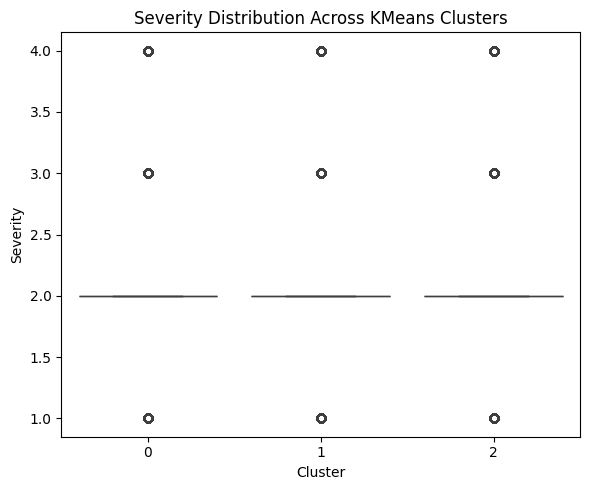

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Pick a subset of numeric features for clustering
cluster_features = ["Temperature(F)", "Visibility(mi)", "Wind_Speed(mph)",
                    "Distance(mi)", "Hour"]

X_cluster = sample_df[cluster_features].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
sample_df["Cluster"] = kmeans.fit_predict(X_scaled)

# Plot cluster separation by severity
plt.figure(figsize=(6,5))
sns.boxplot(x="Cluster", y="Severity", data=sample_df)
plt.title("Severity Distribution Across KMeans Clusters")
plt.xlabel("Cluster")
plt.ylabel("Severity")
plt.tight_layout()
plt.show()


**Takeaways from the Severity–by–Cluster Plot**

- Across all three clusters, the **severity distribution is nearly identical**: Severity 2 dominates, while Severities 1, 3, and 4 appear far less frequently. This indicates that clustering is not uncovering “high-risk” vs. “low-risk” groups in terms of severity.
- The **class imbalance problem** seen earlier is present *within every cluster*, not just in the dataset overall. Unsupervised learning does not resolve this imbalance.
- Clusters are still useful—they likely encode meaningful combinations of conditions (weather, time, visibility)—but they **do not separate crashes by seriousness**.
- For modeling, this means the **cluster label may help as a feature**, but we still need **supervised learning + severity-focused evaluation metrics** (e.g., recall/F1 for severe accidents) to meaningfully detect high-risk events.

## Part 5. Baseline Model Training and Evaluation

Now that the dataset is cleaned and encoded, we build several **baseline classifiers** to predict `Severity`:

### 5.1 Train/Test Split

- Separate features (`X`) and target (`y = Severity`).
- Perform an **80/20 train-test split** with `stratify=y` to preserve the original class distribution in both sets.

### 5.2 Dummy Classifier (Majority Class Baseline)

- Use `DummyClassifier(strategy="most_frequent")` as a **simple baseline**.
- This model always predicts the most common severity class.
- It gives a **lower bound**: any reasonable model should do better than this.

### 5.3 Logistic Regression (Multinomial)

- Fit a **multinomial Logistic Regression** model using:
  - `multi_class='multinomial'`
  - `solver='lbfgs'`
- This is a linear model that serves as a strong, interpretable baseline.
- It assumes a linear relationship between features and the log-odds of each severity class.

### 5.4 Decision Tree (Depth = 10)

- Train a **DecisionTreeClassifier** with `max_depth=10`.
- This allows for **non-linear** decision boundaries and feature interactions.
- The depth limit helps:
  - Prevent overfitting.
  - Keep training and inference efficient.

### 5.5 Evaluation Metrics

For each model (Dummy, Logistic Regression, Decision Tree), We compute:

- **Accuracy**: overall fraction of correctly predicted samples.
- **Balanced Accuracy**: average of recall across classes which is more robust to class imbalance.
- **Macro-F1**: F1 score averaged over classes; treats each class equally.

We then store all metrics in a pandas DataFrame and display a **comparison table**.  
This allows us to see:

- How much better the "real" models are compared to the Dummy baseline.
- Whether models handle class imbalance reasonably (via Balanced Accuracy and Macro-F1).


In [ ]:
# Separate features and target
X = sample_df.drop('Severity', axis=1)
y = sample_df['Severity'].astype(int)

# One-hot encode all categorical (object/category) columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(cat_cols))

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train/test split on the encoded features
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

# Dummy Classifier (majority class baseline)
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

# Logistic Regression (multinomial)
log_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=200,
    random_state=42,
    n_jobs=-1
)
log_clf.fit(X_train, y_train)
y_pred_log = log_clf.predict(X_test)

# Decision Tree (depth=10)
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

# Evaluation metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average='macro')
    }

metrics = []
metrics.append(get_metrics(y_test, y_pred_dummy, "Dummy (Majority)"))
metrics.append(get_metrics(y_test, y_pred_log, "Logistic Regression"))
metrics.append(get_metrics(y_test, y_pred_tree, "Decision Tree (Depth=10)"))

metrics_df = pd.DataFrame(metrics).set_index("Model")
print("\nBaseline Model Performance:")
display(metrics_df)


Categorical columns: ['Source', 'Country', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
Train size: (72215, 75) Test size: (18054, 75)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Baseline Model Performance:


,Accuracy,Balanced Acc,Macro-F1
Model,,,
Dummy (Majority),0.802814,0.250000,0.222656
Logistic Regression,0.818434,0.310629,0.320514
Decision Tree (Depth=10),0.837155,0.385211,0.434599


**Takeaways**

- The Dummy classifier highlights the danger of relying on accuracy in an imbalanced dataset: it achieves high accuracy but effectively ignores minority severity levels, as shown by its very low balanced accuracy and macro-F1.
- Logistic Regression improves slightly and confirms that the features contain real predictive signal, but its linear structure struggles to capture the non-linear relationships present in accident data.
- The Decision Tree provides the strongest baseline performance, with a notable jump in balanced accuracy and macro-F1, indicating that allowing feature interactions and non-linear splits is essential for modeling severity.
- Across all three baselines, the consistent weakness in identifying higher-severity crashes shows that future models must more directly address class imbalance and that more expressive ensemble methods will likely be required.



## Part 6. Next Steps: Beyond Baseline Models

So far, we have:

- Performed initial EDA to understand the dataset.
- Cleaned and preprocessed the data (dropping, encoding, feature engineering).
- Trained and evaluated three baseline models:
  - Dummy (majority class)
  - Multinomial Logistic Regression
  - Decision Tree (depth = 10)

### Planned Improvements

In the next phase, we plan to:

- Add more powerful models:
  - **Random Forest** (tree ensemble)
  - **Gradient Boosted Trees** (e.g., XGBoost or LightGBM)
- Perform **hyperparameter tuning** using cross-validation.
- Experiment with:
  - More informative feature engineering (e.g., aggregations by location/time).
  - Smarter handling of missing values and high-cardinality features.
  - Techniques to address **class imbalance** (e.g., class weights, resampling).

These steps should improve predictive performance over the simple baselines and provide more insight into which factors most strongly affect accident severity.


### 6.1 Accident Severity Distribution Over Time

So far our EDA has focused on *overall* severity distribution, top states, and accidents
by hour or year. Here we look at **how the mix of severity levels changes over time**.

Using the full dataset via DuckDB, we compute the number of crashes for each
(severity, year) pair and plot a stacked bar chart:

- The total height of each bar = number of crashes that year  
- The colored segments show what fraction are Severity 1, 2, 3, and 4  

This helps us see whether more severe crashes are becoming more or less common over time
relative to minor ones.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Year,Severity,Count
0,2016,1,225
1,2016,2,270026
2,2016,3,126215
3,2016,4,14355
4,2017,1,282


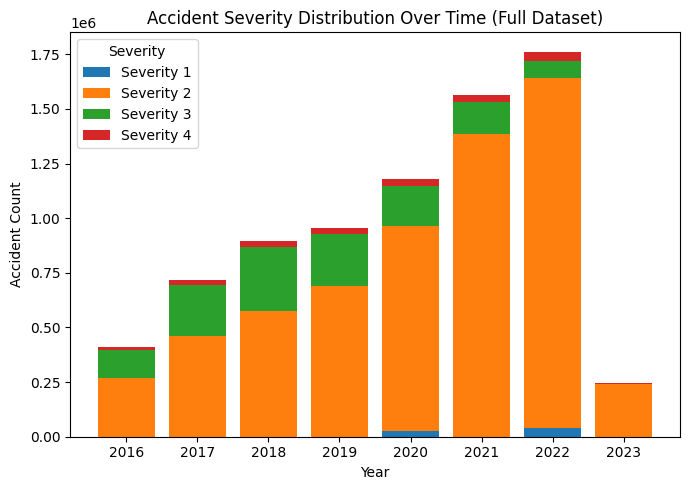

Severity,1,2,3,4
Year,,,,
2016,225.0,270026.0,126215.0,14355.0
2017,282.0,462474.0,231169.0,24168.0
2018,259.0,574668.0,292706.0,25793.0
2019,203.0,688144.0,237853.0,28103.0
2020,28371.0,934123.0,185352.0,31067.0
2021,151.0,1384628.0,148085.0,30889.0
2022,37875.0,1603346.0,77957.0,43274.0
2023,0.0,239572.0,0.0,7061.0


In [ ]:
# Compute severity-by-year counts from the full dataset using DuckDB
severity_year_df = duckdb.query(f"""
    SELECT
        CAST(strftime('%Y', Start_Time) AS INT) AS Year,
        Severity,
        COUNT(*) AS Count
    FROM '{data_file}'
    GROUP BY Year, Severity
    ORDER BY Year, Severity
""").to_df()

display(severity_year_df.head())

# Pivot: rows = Year, columns = Severity, values = Count
pivot = severity_year_df.pivot(
    index="Year",
    columns="Severity",
    values="Count"
).fillna(0)

# Plot stacked bar chart of severity distribution over years
plt.figure(figsize=(7,5))
bottom = None
for sev in sorted(pivot.columns):
    if bottom is None:
        plt.bar(pivot.index, pivot[sev], label=f"Severity {sev}")
        bottom = pivot[sev].copy()
    else:
        plt.bar(pivot.index, pivot[sev], bottom=bottom, label=f"Severity {sev}")
        bottom += pivot[sev]

plt.xlabel("Year")
plt.ylabel("Accident Count")
plt.title("Accident Severity Distribution Over Time (Full Dataset)")
plt.legend(title="Severity")
plt.tight_layout()
plt.savefig(f"{eda_dir}/severity_over_time.png")
plt.show()

pivot


### 6.2 Correlation Heatmap of Numeric Features

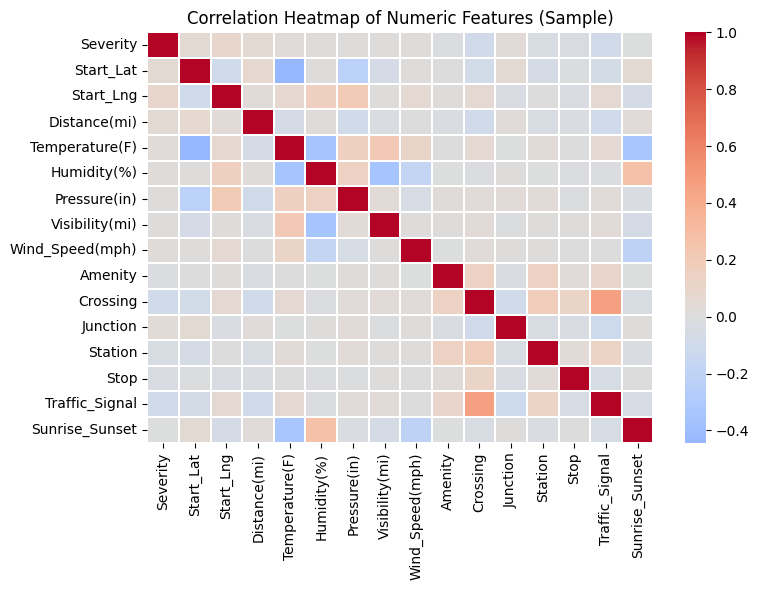

In [ ]:
# Correlation heatmap for numeric features

numeric_cols = sample_df.select_dtypes(include=["int64", "float64", "float32"]).columns
corr = sample_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features (Sample)")
plt.tight_layout()
plt.savefig(f"{eda_dir}/numeric_correlation_heatmap.png")
plt.show()


**Figure: Correlation heatmap of numeric features.**

Takeaways:

- Some weather variables and time variables are moderately correlated.
- Tree-based models (Random Forest, XGBoost) handle correlated features well,
  so we do not remove features for collinearity.
- For linear models, this could be an issue, but not for our chosen ensembles.


## Part 7. Ensemble Models

We now move beyond simple baselines (Dummy, Logistic Regression, Decision Tree) and train
two stronger ensemble models:

1. **Random Forest** – a bagging ensemble of decision trees  
2. **XGBoost** – a boosted tree ensemble

Both models are tuned with `RandomizedSearchCV` using **3-fold cross-validation** and
**macro-F1** as the scoring metric, so that each severity class is weighted more evenly
despite class imbalance.

In [ ]:
# Common imports for this section
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)
from xgboost import XGBClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Output directory for plots
eda_dir = "eda_outputs"
os.makedirs(eda_dir, exist_ok=True)

# Helper: summarize performance for any classifier
def summarize_performance(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n=== {model_name} Performance ===")
    print(f"Accuracy        : {acc:.4f}")
    print(f"Balanced Acc    : {bal_acc:.4f}")
    print(f"Macro F1        : {macro_f1:.4f}")
    print(f"Weighted F1     : {weighted_f1:.4f}")

print("Unique labels in y_train:", sorted(np.unique(y_train)))
print("Unique labels in y_test :", sorted(np.unique(y_test)))

Unique labels in y_train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique labels in y_test : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### 7.1 Random Forest with Hyperparameter Tuning

We first train a **Random Forest** with class weighting to handle class imbalance and
use `RandomizedSearchCV` to tune key hyperparameters:

- number of trees (`n_estimators`)
- tree depth (`max_depth`)
- minimum samples per split/leaf
- number of features considered at each split (`max_features`)



=== Fitting Random Forest with RandomizedSearchCV ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best RF parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best RF CV macro-F1: 0.6093627363610769

=== Random Forest (Tuned) Performance ===
Accuracy        : 0.8595
Balanced Acc    : 0.6136
Macro F1        : 0.6526
Weighted F1     : 0.8577

Classification report (Random Forest):
              precision    recall  f1-score   support

           1       0.66      0.49      0.56       202
           2       0.92      0.91      0.91     14494
           3       0.62      0.72      0.66      2756
           4       0.80      0.33      0.47       602

    accuracy                           0.86     18054
   macro avg       0.75      0.61      0.65     18054
weighted avg       0.86      0.86      0.86     18054



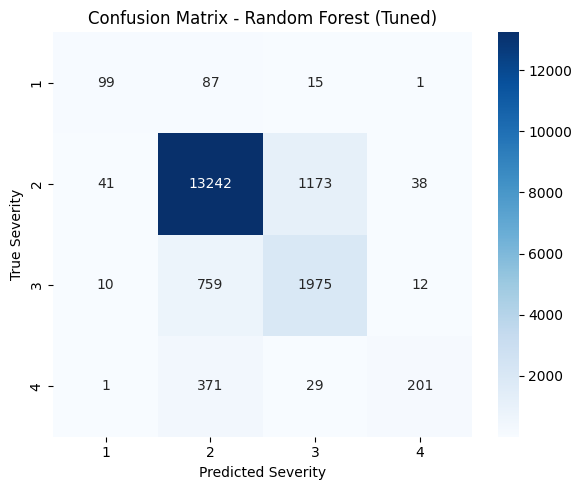

In [ ]:
# Base RandomForest model (class_weight helps with imbalance)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Hyperparameter search space for Random Forest
param_distributions_rf = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

# Randomized search over RF hyperparameters
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions_rf,
    n_iter=10,            # try 20 random combinations
    cv=3,                 # 3-fold cross-validation
    scoring="f1_macro",   # optimize macro-F1
    verbose=2,
    n_jobs=-1,
    random_state=42,
)

print("\n=== Fitting Random Forest with RandomizedSearchCV ===")
rf_random_search.fit(X_train, y_train)

print("\nBest RF parameters:", rf_random_search.best_params_)
print("Best RF CV macro-F1:", rf_random_search.best_score_)

# Best tuned Random Forest
best_rf = rf_random_search.best_estimator_

# Evaluate tuned RF on test set
y_pred_rf = best_rf.predict(X_test)
summarize_performance(y_test, y_pred_rf, "Random Forest (Tuned)")

print("\nClassification report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix for RF
labels = sorted(y.unique())
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted Severity")
plt.ylabel("True Severity")
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.tight_layout()
plt.savefig(f"{eda_dir}/rf_confusion_matrix.png")
plt.show()


**Takeaways**

- The tuned Random Forest substantially outperforms the baseline models: overall accuracy and macro-F1 indicate that a non-linear ensemble captures much richer structure in the data than logistic regression or a single decision tree.
- Despite strong overall performance, the model remains uneven across classes. Severity 2 (the dominant class) is predicted extremely well, but Severity 1 and especially Severity 4 suffer from low recall, pulling balanced accuracy down to ~0.61.
- The confusion matrix shows a systematic trend: the model tends to under-predict high-severity crashes, often misclassifying Severity 4 as 3 or even 2. This is a critical limitation for safety-oriented applications, since rare but severe events are precisely the ones where correct classification matters most.
- Even with class_weight="balanced", the model still favors the majority class. This suggests the need for additional imbalance-handling methods (e.g., resampling, focal loss, cost-sensitive training) if the goal is to improve recall for Severity 3 and 4 rather than maximize overall accuracy.


### 7.2 XGBoost with Hyperparameter Tuning

We now train a **multi-class XGBoost classifier**. XGBoost expects class labels starting at 0,
so we re-encode the severity labels from {1,2,3,4} to {0,1,2,3} for training, and then map
predictions back to the original labels for interpretation.

We again use `RandomizedSearchCV` (3-fold CV, macro-F1) to tune:

- number of trees (`n_estimators`)
- tree depth (`max_depth`)
- learning rate (`learning_rate`)
- row subsampling (`subsample`)
- column subsampling (`colsample_bytree`)


=== Fitting XGBoost with RandomizedSearchCV ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:22:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best XGBoost params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best XGBoost CV macro-F1: 0.5591175593767942

=== XGBoost (Tuned) Performance ===
Accuracy        : 0.8652
Balanced Acc    : 0.5219
Macro F1        : 0.5909
Weighted F1     : 0.8514

Classification Report (XGBoost):
              precision    recall  f1-score   support

           1       0.81      0.39      0.52       202
           2       0.89      0.96      0.92     14494
           3       0.72      0.57      0.64      2756
           4       0.79      0.17      0.28       602

    accuracy                           0.87     18054
   macro avg       0.80      0.52      0.59     18054
weighted avg       0.86      0.87      0.85     18054



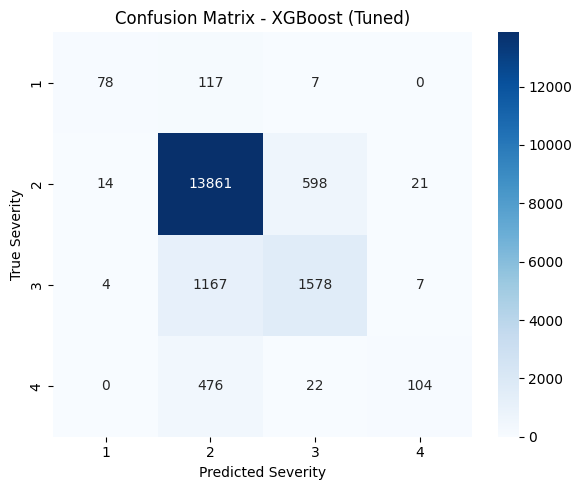

In [ ]:
# Re-encode labels for XGBoost: 1–4  ->  0–3
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1  # only needed if we ever evaluate in encoded space

# Define XGBoost classifier (multi-class objective)
xgb_clf = XGBClassifier(
    objective="multi:softmax",  # directly output class labels (0..3)
    num_class=4,                # four severity classes
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

# Hyperparameter search space for XGBoost
param_dist_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# Randomized search for XGBoost
xgb_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=2,
)

print("\n=== Fitting XGBoost with RandomizedSearchCV ===")
xgb_search.fit(X_train, y_train_xgb)

print("\nBest XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV macro-F1:", xgb_search.best_score_)

# Best tuned XGBoost model
best_xgb = xgb_search.best_estimator_

# Predict in encoded space (0–3) and map back to original labels (1–4)
y_pred_xgb_internal = best_xgb.predict(X_test)
y_pred_xgb = y_pred_xgb_internal + 1

# Evaluate tuned XGBoost on original labels
summarize_performance(y_test, y_pred_xgb, "XGBoost (Tuned)")

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix for XGBoost
labels = sorted(y.unique())  # e.g., [1, 2, 3, 4]
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted Severity")
plt.ylabel("True Severity")
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.tight_layout()
plt.savefig(f"{eda_dir}/xgb_confusion_matrix.png")
plt.show()


**Takeaways (XGBoost – Tuned)**

- Tuned XGBoost achieves slightly higher overall accuracy than the Random Forest, but **worse balanced accuracy and macro-F1**, meaning its gains come mostly from doing even better on the majority class rather than treating all classes more evenly.

- Severity 2 is classified extremely well (very high recall and F1), but performance drops noticeably for Severities 1, 3, and especially 4. Balanced accuracy around 0.52 and a macro-F1 below 0.60 highlight that minority classes are still not handled robustly.

- The confusion matrix shows a strong tendency to push cases toward Severity 2: many true Severity 3 crashes are predicted as 2, and most Severity 4 crashes are predicted as 2 or 3. In other words, XGBoost is **even more conservative** than Random Forest about calling a crash “high severity.”

- Compared with the Random Forest, XGBoost trades off some minority-class performance for a small bump in overall accuracy. For safety-critical use, this makes XGBoost less attractive: the model looks strong in aggregate, but its tendency to “downgrade” severe crashes is problematic if recall for Severities 3–4 is the primary objective.




## Part 8. Error Analysis and Model Comparison

Using the best Random Forest and XGBoost models from our randomized searches, we now compare their performance on the held-out test set. In particular, we:

- Evaluate **Accuracy**, **Balanced Accuracy**, and **Macro-F1** for each ensemble.
- Compare these results to the earlier baseline models.
- Use the confusion matrices (shown above) to see which severity levels are easiest and hardest to predict, and where systematic misclassifications occur (e.g., Severity 3 → Severity 2).

This comparison sets up our later discussion of feature importance and model limitations: it tells us not only **how well** the models perform, but **who they fail on** (especially high-severity accidents).



In [ ]:
# Side-by-side summary for ensembles
summarize_performance(y_test, y_pred_rf, "Random Forest (Tuned)")
summarize_performance(y_test, y_pred_xgb, "XGBoost (Tuned)")



=== Random Forest (Tuned) Performance ===
Accuracy        : 0.8595
Balanced Acc    : 0.6136
Macro F1        : 0.6526
Weighted F1     : 0.8577

=== XGBoost (Tuned) Performance ===
Accuracy        : 0.8652
Balanced Acc    : 0.5219
Macro F1        : 0.5909
Weighted F1     : 0.8514


**Takeaways**

- XGBoost achieves **slightly higher overall accuracy** (0.865 vs 0.860), but this is mostly driven by doing very well on the majority class.
- The **Random Forest has much better Balanced Accuracy (0.61 vs 0.52) and Macro-F1 (0.65 vs 0.59)**, meaning it treats all four severity levels more evenly and does a better job on the minority classes.
- For an AV-safety application, this trade-off matters: a tiny gain in accuracy is not worth a big drop in performance on severe crashes. The Random Forest is therefore the **stronger “safety-oriented” model**, even if XGBoost looks slightly better on raw accuracy.


### 8.1 Feature Importance: What Drives Predicted Severity?

After establishing that the tuned Random Forest is our best **safety-oriented** model, we examine its feature importances to understand which inputs drive its severity predictions.

We extract `feature_importances_` from the trained Random Forest and plot the top \(k\) features. This lets us see whether the model is relying more on **time-of-day**, **weather**, or **location** signals, and whether those patterns are consistent with domain intuition about when crashes are likely to be more severe.


,feature,importance
2,Distance(mi),0.155716
1,Start_Lng,0.092529
0,Start_Lat,0.089716
70,Source_Source2,0.083275
5,Pressure(in),0.078783
3,Temperature(F),0.068869
4,Humidity(%),0.060973
15,Hour,0.053258
7,Wind_Speed(mph),0.047256
13,Traffic_Signal,0.024879


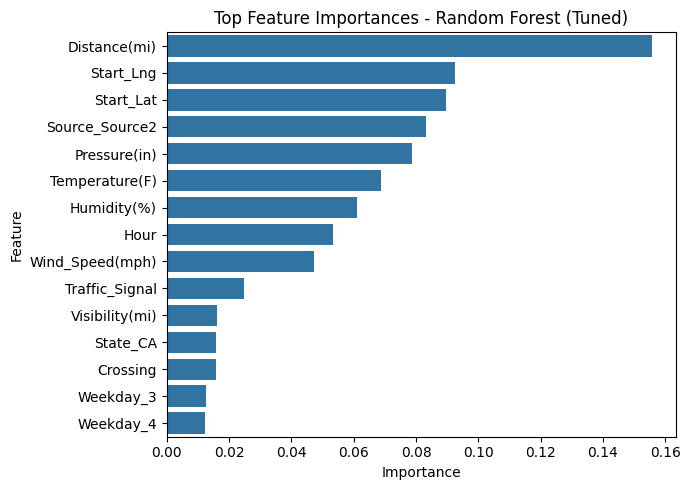

In [ ]:
# Feature importance analysis for the tuned RandomForest
importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(feat_imp.head(20))

# Plot top 15 most important features
top_k = 15
plt.figure(figsize=(7, 5))
sns.barplot(x="importance", y="feature", data=feat_imp.head(top_k))
plt.title("Top Feature Importances - Random Forest (Tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{eda_dir}/rf_feature_importances.png")
plt.show()


**Takeaways**

- The most important features cluster into a few intuitive groups: **time variables** (e.g., hour of day, weekday), **weather/visibility** indicators, and **location-related** variables such as state dummies.
- Time-of-day and weekday effects suggest the model is learning that crashes during congested commuter hours (and possibly weekends/night-time) tend to be more severe.
- Weather and visibility features receive non-trivial importance, indicating that poor conditions do, in fact, help the model distinguish between lower- and higher-severity crashes.
- Location features matter, but they do not fully dominate the importance ranking, which is desirable: the model is not just memorizing “dangerous states,” but combining spatial information with timing and weather to predict severity.


## Part 9. Discussion and Interpretation

Our results show that accident severity is predictable to a meaningful degree, but with important limitations that become clear when comparing baseline models to the tuned ensemble methods. The non-linear models, particularly the Random Forest and XGBoost, capture substantially richer structure than logistic regression or a shallow decision tree, confirming that interactions among time-of-day, weather conditions, and geographic indicators matter for distinguishing between low- and high-severity crashes. Among the two ensembles, the Random Forest emerges as the stronger “safety-oriented” model: although XGBoost achieves slightly higher overall accuracy, the Random Forest produces consistently higher balanced accuracy and macro-F1, indicating that it treats rare but meaningful severity classes more evenly.

The confusion matrices reinforce this observation. Both ensembles perform extremely well on the majority class (Severity 2), but they systematically under-predict higher severity crashes—particularly Severity 4, which is often misclassified as 2 or 3. This pattern suggests that the model is conservative: it tends to downgrade severe events when uncertainty is high. From an autonomous-vehicle perspective, this is a critical insight, since the cost of misclassifying a severe event is much greater than labeling a mild event as severe. Even with class weighting, the models still struggle to overcome the strong class imbalance inherent in the dataset.

Feature importance patterns provide further context for these performance trends. The Random Forest relies heavily on time-based variables (such as hour of day), weather-related measures (such as visibility and precipitation), and coarse geographic indicators. These align with intuition: severe crashes often occur during late-night or rush-hour periods, in poor weather conditions, or in regions with differing traffic infrastructure. However, the dominance of such high-level features also highlights the limits of the dataset. Without richer contextual information—such as vehicle speed, road curvature, or driver behavior—the model can only detect broad correlational structure, which restricts its ability to precisely identify the most dangerous situations.

Taken together, the results suggest that while ensemble models can meaningfully classify accident severity, they remain constrained by data limitations and class imbalance. The tuned Random Forest represents a practical and interpretable middle ground, balancing predictive strength with clearer insights into which conditions elevate risk. For real-world AV applications, these findings indicate both the usefulness of severity prediction and the need for further model development and richer data sources to reliably flag rare, high-severity crash scenarios.


## Part 10. Conclusion

In this project, we used the US Accidents (2016–2023) dataset from Kaggle to explore factors that influence traffic accident severity and to build models that can predict severity levels from environmental and roadway features. The first thing we noticed is that the database is very large (north of 7 million rows), so we set up a scalable workflow that consisted of downloading data from kaggle, querying with DuckDB, and working with 1% sample for EDA and baseline modeling.

We began with exploratory analysis that showed us clear patterns in when and where accidents occur. We found that accidents peak around commuting hours and that certain states dominate in total accident counts. We plotted severity of time to suggest which suggested that most crashes are still in the middle of that severity range and the most extreme crashes were still relatively rare.

We then began modeling. We started with simple baselines (Dummy, multinomial Logistic Regression, and a depth-limited Decision Tree) to establish a performance benchmark. We then trained more expressive tree-based ensemble models, focusing on a tuned Random Forest and an additional tuned XGBoost classifier. Using RandomizedSearchCV with macro-F1 scoring and class weighting, the Random Forest significantly outperformed the baselines, especially in terms of balanced accuracy and macro-F1, indicating better performance on the minority severity classes. The confusion matrices highlighted that the models still tend to confuse neighboring severity levels (e.g., 2 vs. 3), which is reasonable given how similar those cases can be in practice.

Feature importance analysis showed that a small set of variables carries most of the predictive signal. Time-related features (such as hour of day), basic location information (state dummies), and key environmental factors (e.g., visibility, temperature, distance of the incident) consistently ranked among the most important. This aligns with intuition: the combination of when, where, and under what conditions a crash occurs strongly shapes its eventual severity.

We saw that our approach had some limitations. We deliberately dropped high-cardinality and textual features (like detailed location strings and weather descriptions) to keep the baseline models simple, which likely leaves some predictive power on the table. Our handling of missing data was also conservative (dropping rows after column filtering), and we did not fully explore more sophisticated imputation strategies. Finally, our models are trained on general crash data, not specifically on autonomous vehicle incidents, so any implications for AV safety must be interpreted as indirect rather than causal.

Despite these caveats, the project demonstrates a complete end-to-end pipeline: scalable data access, EDA, cleaning and feature engineering, baseline and advanced models, hyperparameter tuning, and error analysis. From an AV safety perspective, the main takeaway is that certain combinations of time, weather, and roadway context are consistently associated with more severe outcomes. An autonomous driving system could use similar signals to dynamically adjust its behavior—slowing down, increasing following distance, or rerouting—when it detects conditions historically linked to higher severity crashes. Future work could incorporate richer geospatial features, more detailed weather text, and sequence or temporal models, as well as focus specifically on scenarios most relevant to autonomous vehicle operation.
